In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from feynman import Diagram



In [90]:
#plt.style.use('dark_background')
plt.style.use('default')
#Установка красивого шрифта
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
plt.rcParams['mathtext.fontset'] = 'cm'

main_color = "black"

In [190]:
class Theme:
    theme = "light"
    @staticmethod
    def set(_theme):
        Theme.theme = _theme
        if(Theme.theme == "dark"):
            plt.style.use('dark_background')
        else:
            plt.style.use('default')
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
        plt.rcParams['mathtext.fontset'] = 'cm'
    @staticmethod
    def color():
        if(Theme.theme == "light"):
            return "black"
        else:
            return "white"
    @staticmethod
    def back():
        if(Theme.theme == "light"):
            return "white"
        else:
            return "black"
    @staticmethod
    def suff():
        if(Theme.theme == "light"):
            return "l"
        else:
            return "d"

## Unitary triangle

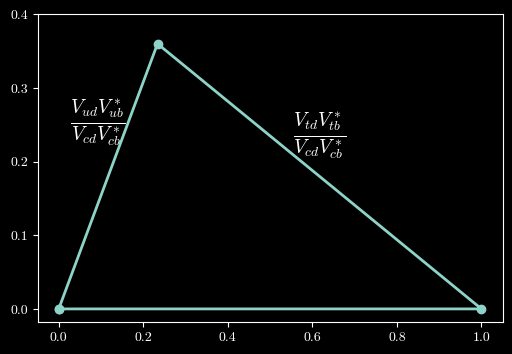

In [ ]:
import numpy as np
Theme.set("dark")

Vud, Vus, Vub = 0.974, 0.227, 0.004 * np.exp(-1j * np.deg2rad(57))
Vcd, Vcs, Vcb = 0.227, 0.973, 0.04
Vtd, Vts, Vtb = 0.008 * np.exp(-1j * np.deg2rad(57)), 0.04, 0.999

A = Vud * np.conj(Vub) / (Vcd * np.conj(Vcb))
B = 1  # единичный вектор (середина)
C = Vtd * np.conj(Vtb) / (Vcd * np.conj(Vcb))

z0 = 0
z1 = B
z2 = A

triangle = np.array([z0, z1, z2, z0])


plt.figure(figsize=(6,4))

plt.plot(triangle.real, triangle.imag, '-o', lw=2)

Ztext = 0.75*z2+0.38*z1
plt.text(Ztext.real, Ztext.imag, '$\\frac{V_{td}V_{tb}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')
Ztext1 = 0.8*z2-0.16
plt.text(Ztext1.real, Ztext1.imag, '$\\frac{V_{ud}V_{ub}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')

plt.yticks([0,0.1,0.2,0.3,0.4])
plt.axis()
plt.savefig('../docs/KaonDecay/CKM/images/unitary-triangle-d.svg',transparent=True)
plt.show()



## Diagramm n->p

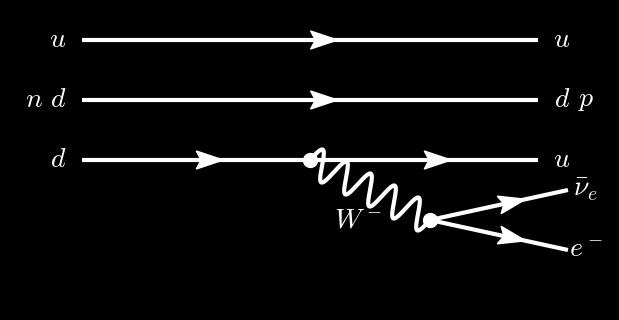

In [256]:


#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,5*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.5)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.5
# Вершины
in1 = diagram.vertex(xy=(dX+0.12, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.12, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона
in3 = diagram.vertex(xy=(dX+0.12, image_h-0.25), marker='', **style_params)  # d-кварк нейтрона

out1 = diagram.vertex(xy=(dX+0.88, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.88, image_h-0.15), marker='', **style_params)  # d-кварк протона
out3 = diagram.vertex(xy=(dX+0.88, image_h-0.25), marker='', **style_params)  # u-кварк протона

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.25), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.35), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.93, image_h-0.4), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.93, image_h-0.3), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(in1, out1, **style_params, arrow_param=style_params)
d_line1 = diagram.line(in2, out2, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in3, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out3, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.08, image_h-0.25, r"$d$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.92, image_h-0.25, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.03, out_e.xy[1], r"$e^-$", fontsize=20)
diagram.text(out_nu.xy[0]+0.03, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.96, image_h-0.15, r"$p$", fontsize=20)
diagram.text(dX+0.04, image_h-0.15, r"$n$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/n-decay-{Theme.suff()}.svg',transparent=True)

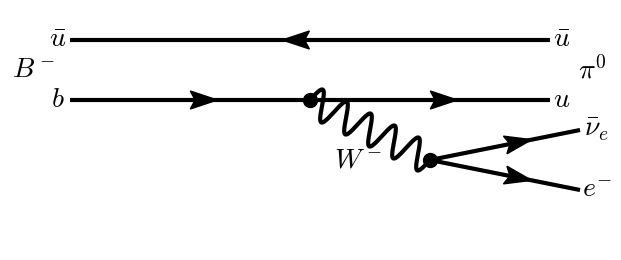

In [250]:

Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,4*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
# Вершины
in1 = diagram.vertex(xy=(dX+0.1, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.1, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона=

out1 = diagram.vertex(xy=(dX+0.9, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.9, image_h-0.15), marker='', **style_params)  # d-кварк протона=

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.15), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.25), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.95, image_h-0.3), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.95, image_h-0.2), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(out1, in1, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in2, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out2, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$b$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.028, out_e.xy[1], r"$e^{-}$", fontsize=20)
diagram.text(out_nu.xy[0]+0.028, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.97, image_h-0.1, r"$\pi^0$", fontsize=20)
diagram.text(dX+0.04, image_h-0.1, r"$B^-$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/B-decay-{Theme.suff()}.svg',transparent=True)

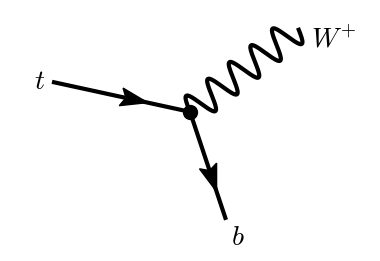

In [ ]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
cw= 0.3
# Вершины
in1 = diagram.vertex(xy=(cw-0.23, 0.28), marker='', **style_params) 
cener = diagram.vertex(xy=(cw, 0.23), **style_params) 
outW = diagram.vertex(xy=(cw+0.18, 0.37), marker='', **style_params)  
outq = diagram.vertex(xy=(cw+0.06, 0.05), marker='', **style_params)  


tin_line = diagram.line(in1, cener, **style_params, arrow_param=style_params)
qout_line = diagram.line(cener, outq, **style_params, arrow_param=style_params)
w_line = diagram.line(cener, outW, style='wiggly', **style_params)

diagram.text(in1.xy[0]-0.02, in1.xy[1], r"$t$", fontsize=20)
diagram.text(outq.xy[0]+0.02, outq.xy[1]-0.03, r"$b$", fontsize=20)
diagram.text(outW.xy[0]+0.06, outW.xy[1]-0.02, r"$W^{+}$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/tq-decay-{Theme.suff()}.svg',transparent=True)

## Phi 4

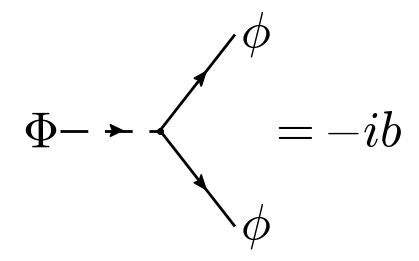

In [317]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.2), marker='', **style_params) 
center = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.45, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.45, H-0.04), marker='', **style_params)

diagram.line(in1, center, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.04, in1.xy[1]-0.005, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1], r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1], r"$\phi$", fontsize=36)

diagram.text(out2.xy[0]+0.2, center.xy[1]-0.005, r"$=-ib$", fontsize=36)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Phi-2phi-{Theme.suff()}.svg',transparent=True)

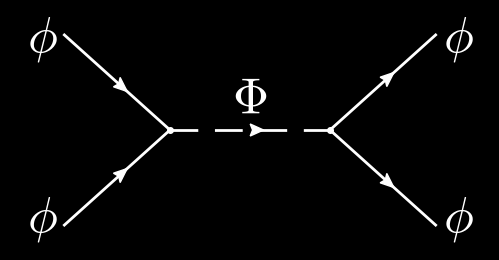

In [341]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4-{Theme.suff()}.svg',transparent=True)

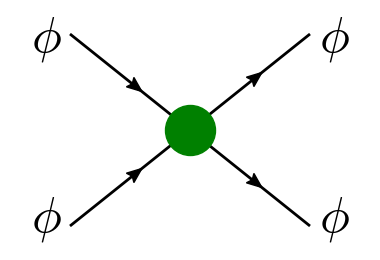

In [361]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), color="green",markersize=36)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_Full-{Theme.suff()}.svg',transparent=True)

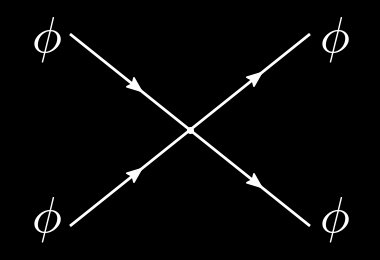

In [363]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_EFT-{Theme.suff()}.svg',transparent=True)

In [371]:
2.4*1/0.4

5.999999999999999

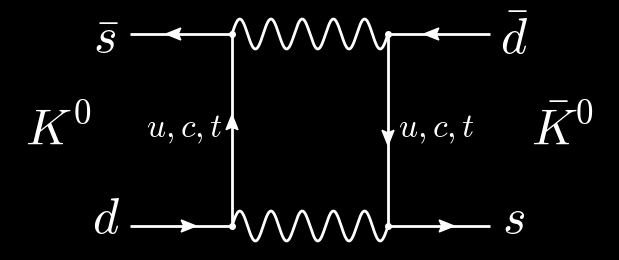

In [393]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center2_d,  **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)
diagram.text(out1.xy[0]+0.12,H/2, r"$\bar{K}^0$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.08, H/2, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{d}$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Kosc-{Theme.suff()}.svg',transparent=True)

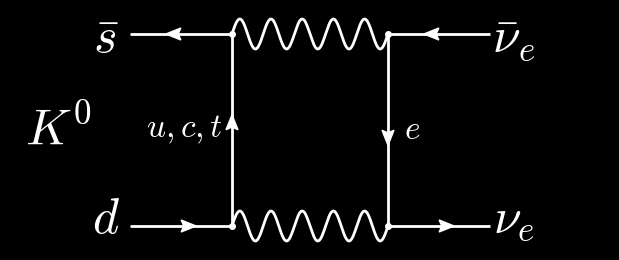

In [404]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2_d, **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.04, H/2, r"$e$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\nu_e$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{\nu}_e$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/KLDecay-{Theme.suff()}.svg',transparent=True)

## Decay $ b \to s + \gamma $

In [ ]:
from feynman import Line

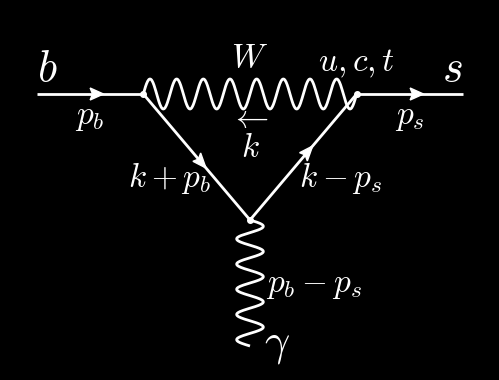

In [473]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,style='wiggly',nwiggles=8,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.06, r"$W$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(center2.xy[0], center2.xy[1]+0.05, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.05, H/2+0.02, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.03, H/2+0.02, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_1-{Theme.suff()}.svg',transparent=True)

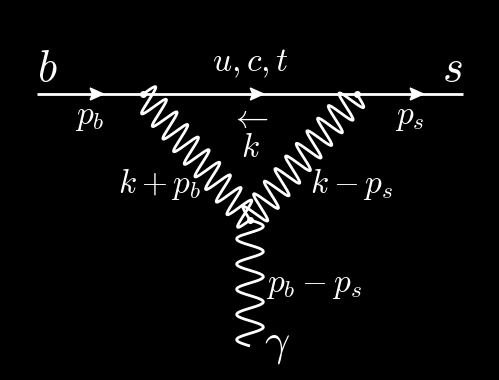

In [486]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$u,c,t$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.03, H/2+0.01, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.01, H/2+0.01, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_2-{Theme.suff()}.svg',transparent=True)